# 03 — LDA topics

TF-IDF told us what one article is *about* by distinctive words. **LDA**
(Latent Dirichlet Allocation) tries something bigger: discover a handful of
recurring **topics** across the whole corpus, where each topic is a
distribution over words and each article is a mixture of topics.

**Honesty first (from CLAUDE.md 'Corpus reality'):** 81 short documents is
*below* where LDA topics are stable. Expect wobbly, hard-to-name topics that
shift when you re-run or change `n_components`. That's not you doing it wrong —
it's the data being small. The goal here is to *see that instability first-hand*
and form a view on whether a different unit (paragraphs?) would help.

## One thing that changes vs notebook 02

LDA models **word counts**, not TF-IDF weights. TF-IDF's whole point is to
down-weight common words; LDA wants the raw counts and handles commonness
itself. So we rebuild the matrix with `CountVectorizer` instead of
`TfidfVectorizer`. Same knobs otherwise, so topics stay comparable to what we
saw before.

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

df = pd.read_parquet("../data/corpus.parquet")
df.shape  # 81 rows — same corpus as notebook 02

(81, 6)

In [2]:
# Counts, not TF-IDF. Reuse the same knobs as 02 so results stay comparable.
vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    max_df=0.9,
    min_df=2,
)
X = vectorizer.fit_transform(df["body"]) # We take the body of the content here, not the headline. Headline is too short to be useful for LDA.
terms = vectorizer.get_feature_names_out()
X.shape   # (81, vocab_size)

(81, 1488)

In [3]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6516 stored elements and shape (81, 1488)>
  Coords	Values
  (0, 172)	7
  (0, 993)	2
  (0, 616)	1
  (0, 587)	1
  (0, 481)	1
  (0, 341)	3
  (0, 242)	1
  (0, 1138)	1
  (0, 1065)	1
  (0, 518)	3
  (0, 1173)	2
  (0, 1319)	5
  (0, 1484)	1
  (0, 1071)	1
  (0, 399)	1
  (0, 293)	1
  (0, 1394)	1
  (0, 184)	1
  (0, 1431)	1
  (0, 232)	1
  (0, 479)	3
  (0, 1092)	2
  (0, 1266)	1
  (0, 603)	1
  (0, 1356)	1
  :	:
  (80, 1285)	1
  (80, 1468)	1
  (80, 239)	1
  (80, 772)	1
  (80, 566)	1
  (80, 291)	1
  (80, 768)	1
  (80, 1305)	1
  (80, 1306)	1
  (80, 908)	1
  (80, 1338)	1
  (80, 861)	1
  (80, 911)	1
  (80, 46)	1
  (80, 1301)	1
  (80, 1303)	1
  (80, 80)	1
  (80, 1329)	1
  (80, 605)	1
  (80, 81)	1
  (80, 1103)	1
  (80, 1081)	1
  (80, 47)	1
  (80, 589)	1
  (80, 1284)	1


## Fit LDA

The one knob you must choose is **`n_components`** — how many topics to look
for. There is no correct value; it's a modelling choice you defend. With 81
docs, start small (4–6) — more topics just splits thin data thinner.

`random_state` fixes the randomness so a re-run gives the same topics (useful
while learning; change it later to *test stability* — do topics survive a
different seed?).

In [4]:
#   - make a LatentDirichletAllocation(n_components=?, random_state=0)
#   - .fit(X)
#   - after fitting, lda.components_ has shape (n_topics, vocab_size):
#     one row per topic, each row is that topic's weight over every word.
#   Check: what is lda.components_.shape? Does it match what you expect? Yeap 5 topics against 1488 tokens
n_topics = 5
lda = LatentDirichletAllocation(n_components=n_topics, random_state=0)
lda.fit(X)
lda.components_.shape

(5, 1488)

## Read the topics

A topic has no name — it's just a row of word weights. You *name it yourself*
by reading its top words. This is the exact same 'sort a weight vector, map
indices back through `terms`' move you did for TF-IDF top-terms — just applied
to `lda.components_[t]` (a topic) instead of `X[i]` (a document).

In [5]:
for t in range(n_topics):
    comp = lda.components_[t]              # this topic's word weights
    top_idx = np.argsort(comp)[::-1][:10]  # 10 biggest — same trick as 02
    words = [terms[j] for j in top_idx]
    print(t, words)
#   Then: can you give each topic a one-word human label? If you can't, that's
#   a finding about the corpus, not a failure.

0 ['final', 'cup', 'half', 'minutes', 'centre', 'newcastle', 'forward', 'villa', 'goal', 'centre forward']
1 ['cup', 'final', 'time', 'fa', 'scottish', 'clubs', 'players', 'second', 'england', 'old']
2 ['league', 'players', 'cup', 'final', 'football', 'half', 'newcastle', 'war', 'leeds', 'park']
3 ['league', 'villa', 'sunderland', 'season', 'cup', 'points', 'goal', 'win', 'clubs', 'division']
4 ['england', 'match', 'goals', 'scotland', 'half', 'season', 'won', 'played', 'time', 'war']


## Which topic is each article?

`lda.transform(X)` returns an (81 × n_topics) matrix: each row is how much of
each topic that article is made of (rows sum to ~1). The article's dominant
topic is the `argmax` of its row.

In [6]:
doc_topics = lda.transform(X)         # (81, n_topics)
df["topic"] = doc_topics.argmax(axis=1)
#   Then eyeball it:
df["topic"].value_counts()          #-> are topics balanced or lopsided?

topic
1    21
4    19
3    17
0    16
2     8
Name: count, dtype: int64

From the 81 article headlines, we have majority in topic 1 then 4 and last 2. Topic 1 seems to be the most popular topic to talk about.

In [7]:
df.loc[df["topic"] == 0, "headline"] #-> do those headlines feel related?
#   - does topic line up at all with era_label? (crosstab)

3                                      Ten Irish heroes
4                             A great day for the Irish
5                          King at Palace for Cup final
8                                   The Khaki Cup final
9                               The man who wouldn't go
26              Villa spoil Newcastle's 'double' dreams
27                     Newcastle make up for Cup defeat
28                         Promoted Liverpool win title
29    Raisbeck is the rock on which England's forwar...
30                  Everton make it a Merseyside double
34                 Newcastle's Cup 'jinx' strikes again
41                                            Villa men
43                                           Custodians
49                            New Cup stays in Bradford
68                        Sheffield on the razor's edge
76                                Non-Leaguers 'Buryed'
Name: headline, dtype: str

## Reflection — the honest bit

Sit with these before moving on; the answers shape the RAG step:

- **Stability:** re-fit with `random_state=1`. Do the same topics come back, or
  do they scramble? Unstable topics = the corpus is too small for this unit.
- **Nameability:** could you actually name every topic, or were some a word
  salad? Un-nameable topics are a real result to report, not a bug to hide.
- **Better unit?** Would paragraphs or sentences (more, shorter docs) give LDA
  more to work with — or just fragment the football matches further? This feeds
  the open 'what is a document?' decision.

**What we actually saw (5 topics, seed 0):** every topic's top words are
football-generic — `cup`, `final`, `half`, `league`, `goal` recur across
*several* topics at once. That word-smearing, not the number of topics, is why
they're hard to name. See `CONCEPTS.md` → 'Why the LDA topics were hard to name'.

## Domain-stopword pass — testing the diagnosis

The first run's topics all shared `cup`, `final`, `half`, `league`, `goal` —
football-generic words that appear everywhere, so LDA can't use them to
*separate* topics. TF-IDF would crush them; LDA keeps raw counts, so nothing
does. The test: drop those words and re-fit. If topics sharpen, the problem was
vocabulary. If they stay mushy, the problem is n=81 (too few docs) — and that's
the finding.

`DOMAIN_STOPWORDS` below is **the experiment** — edit it, re-run, compare. Note
we union it with sklearn's English list, because passing a custom `stop_words`
list replaces the built-in `"english"` rather than adding to it.

In [8]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Football-generic: common across the whole book, so useless for separating
# topics. This list is the whole experiment — add/remove and watch the topics.
DOMAIN_STOPWORDS = {
    "cup", "final", "league", "goal", "goals", "half", "match", "season",
    "time", "played", "play", "club", "clubs", "football", "won", "win",
    "team", "game", "games", "players", "player",
}
stopwords = list(ENGLISH_STOP_WORDS | DOMAIN_STOPWORDS) # Adds both stopwords sets together.

vec2 = CountVectorizer(
    lowercase=True,
    stop_words=stopwords,
    ngram_range=(1, 2),
    max_df=0.9,
    min_df=2,
)
X2 = vec2.fit_transform(df["body"])
terms2 = vec2.get_feature_names_out()
print("vocab:", X2.shape[1], "(was 1488)")

lda2 = LatentDirichletAllocation(n_components=n_topics, random_state=0)
lda2.fit(X2)

for t in range(n_topics):
    top = np.argsort(lda2.components_[t])[::-1][:10]
    print(t, [terms2[j] for j in top])
# Can you name them now? Compare to the first run's topics.

vocab: 1322 (was 1488)
0 ['england', 'villa', 'centre', 'scotland', 'forward', 'fa', 'right', 'sunderland', 'championship', 'minutes']
1 ['second', 'replay', 'newcastle', 'record', 'celtic', 'park', 'scottish', 'minutes', 'lost', 'referee']
2 ['war', 'winners', 'sheffield', 'bolton', 'second', 'took', 'end', 'right', 'went', 'rangers']
3 ['division', 'second', 'rovers', 'leeds', 'albion', 'beat', 'record', 'second division', 'minutes', 'united']
4 ['war', 'rules', 'quinn', 'scottish', 'celtic', 'manchester', 'points', 'association', 'united', 'rangers']


## Visualising the topics

Two honest views for a corpus this size (both use the stopword-pass model):

1. **Article × topic heatmap** — is each article *decisively* one topic, or
   smeared across several? Lots of mid-range colour = weak, overlapping topics.
2. **Topic × era heatmap** — do topics track the timeline? This is the one that
   speaks to the real research question (does coverage shift across the WWI
   break?). If topics line up with eras, that's a signal worth chasing.

*(On `pyLDAvis`: it's the classic interactive LDA viz, but it's a heavy extra
dependency and its intertopic-distance map is unreliable with only 5 topics /
81 docs — it'll look impressive and mean little here. Skipping it on purpose.)*

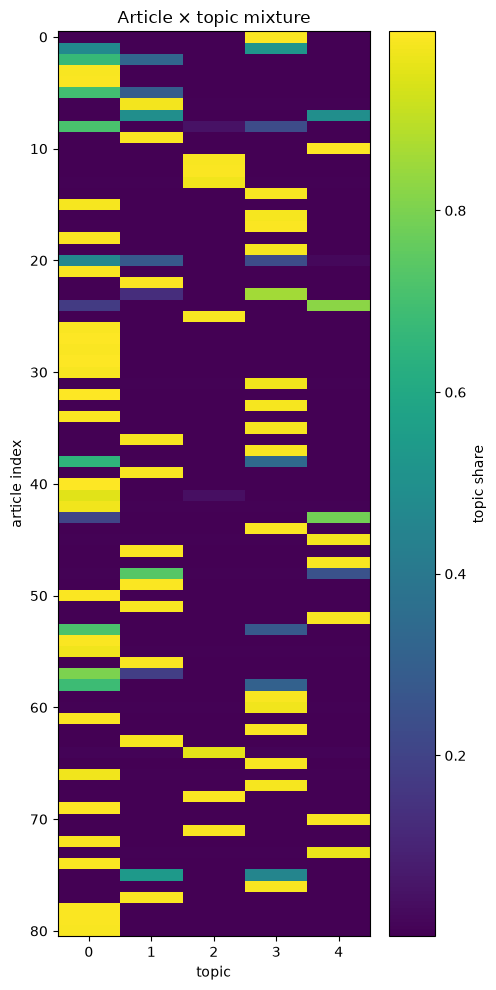

In [9]:
import matplotlib.pyplot as plt

doc_topics2 = lda2.transform(X2)          # (81, n_topics)

fig, ax = plt.subplots(figsize=(5, 10))
im = ax.imshow(doc_topics2, aspect="auto", cmap="viridis")
ax.set_xlabel("topic")
ax.set_ylabel("article index")
ax.set_xticks(range(n_topics))
ax.set_title("Article \u00d7 topic mixture")
fig.colorbar(im, ax=ax, label="topic share")
plt.tight_layout()
plt.show()

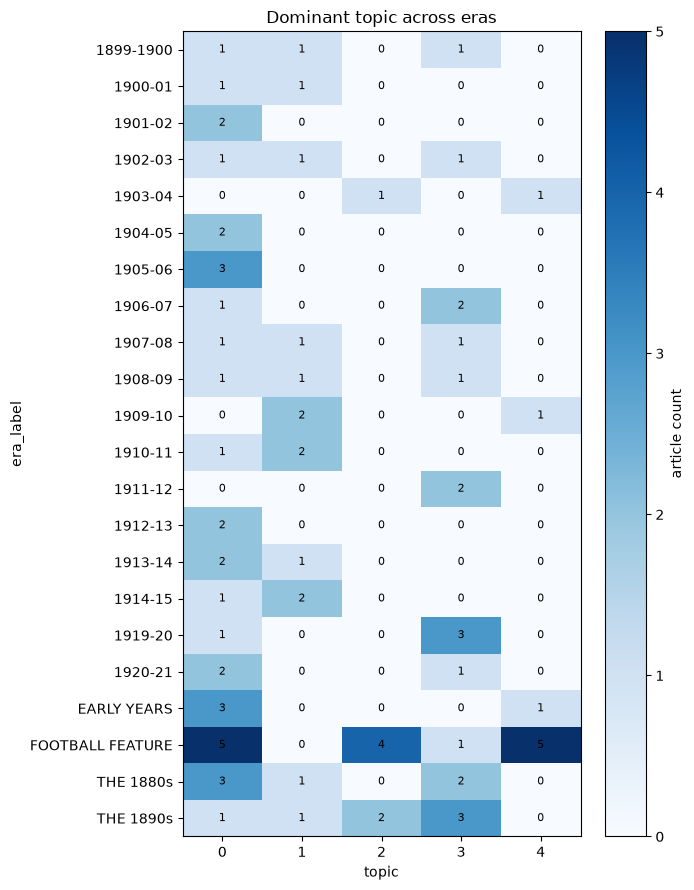

In [10]:
# Topic \u00d7 era: does the dominant topic track the timeline?
df["topic2"] = doc_topics2.argmax(axis=1)
ct = pd.crosstab(df["era_label"], df["topic2"])

fig, ax = plt.subplots(figsize=(7, 9))
im = ax.imshow(ct.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(ct.shape[1])); ax.set_xticklabels(ct.columns)
ax.set_yticks(range(ct.shape[0])); ax.set_yticklabels(ct.index)
ax.set_xlabel("topic"); ax.set_ylabel("era_label")
ax.set_title("Dominant topic across eras")
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, ct.values[i, j], ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="article count")
plt.tight_layout()
plt.show()

Reflection on the two graphs above:
1. Topics are shared across articles, mostly one topic per article but there are some with more than one.
2. The football feature contains the most topics, maekes sense since Football Feature can talk about different topics within the same article.